In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully')

Libraries imported successfully


In [4]:
df=pd.read_csv('sales.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [6]:
df.shape

(200, 4)

In [7]:
print('Total NULL values in dataset: ',df.isnull().sum().sum())

Total NULL values in dataset:  0


In [11]:
X = df.drop('Sales',axis=1)
y=df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape}')
print(f'Testing samples: {X_test.shape}')

Training samples: (160, 3)
Testing samples: (40, 3)


In [12]:
model=LinearRegression()
model.fit(X_train,y_train)
print('Model trained successfuly')

Model trained successfuly


In [16]:
print(f'Slope: {model.intercept_}')
print(f'Intercepts: {model.coef_}')

Slope: 4.714126402214127
Intercepts: [0.05450927 0.10094536 0.00433665]


In [23]:
y_pred = model.predict(X_test)
print(f'Accuracy: {r2_score(y_test,y_pred)}')
print(f'MAE: {mean_absolute_error(y_test,y_pred)}')
print(f'MSE: {mean_squared_error(y_test,y_pred)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test,y_pred))}')

Accuracy: 0.9059011844150826
MAE: 1.2748262109549338
MSE: 2.9077569102710896
RMSE: 1.7052146229349223


In [24]:
check=model.predict([[230.1, 56.3, 67.3]])
print(check)

[23.23178986]


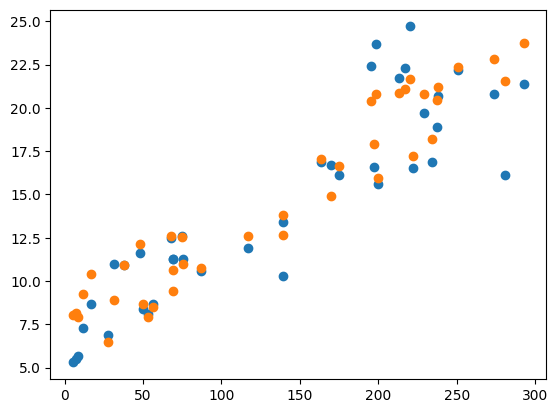

In [25]:
plt.scatter(X_test['TV'],y_test)
plt.scatter(X_test['TV'],y_pred)
plt.show()

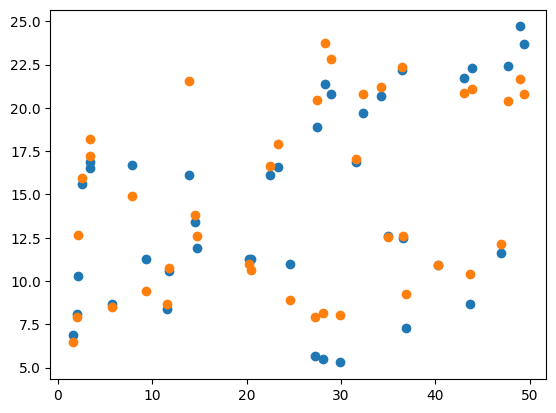

In [26]:
plt.scatter(X_test['Radio'],y_test)
plt.scatter(X_test['Radio'],y_pred)
plt.show()

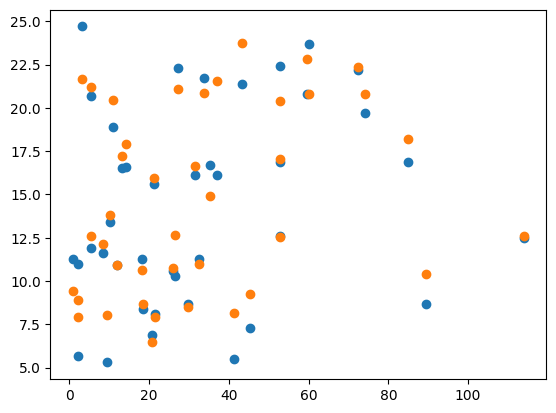

In [27]:
plt.scatter(X_test['Newspaper'],y_test)
plt.scatter(X_test['Newspaper'],y_pred)
plt.show()

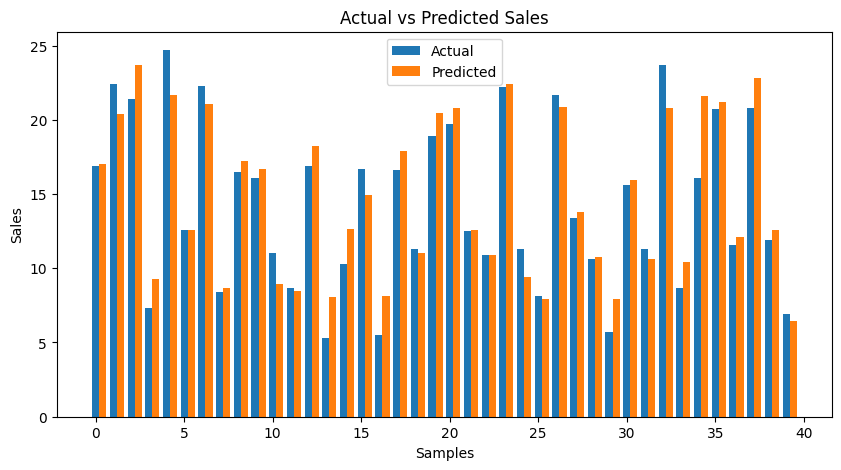

In [28]:
plt.figure(figsize=(10,5))

x = range(len(y_test))

plt.bar(x, y_test, width=0.4, label='Actual')
plt.bar([i+0.4 for i in x],
        y_pred,
        width=0.4,
        label='Predicted')

plt.xlabel('Samples')
plt.ylabel('Sales')

plt.title('Actual vs Predicted Sales')

plt.legend()

plt.show()